# Extension 3 — NFHS-4 to NFHS-5 temporal comparison

This analysis compares wave-specific, survey-weighted adjusted public/private
Cesarean associations. It does not estimate a sector-switch or policy effect.
NFHS-4 uses IABR74FL; NFHS-5 uses the frozen V2 processed cohort. The numeric
v024 state codes differ and are mapped to 35 common units in state_crosswalk.py.
The primary model uses eight mapped adjustment variables. A separate,
pre-specified six-variable sensitivity omits state and social group. Confidence
intervals are provisional conditional PSU-bootstrap intervals because nuisance
fits are fixed and final design variance remains under review. This notebook contains no precomputed results.


## 1. Imports, shared config/utils

In [15]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Work whether Jupyter starts in the extension folder or at the repo root.
for candidate in (Path.cwd(), *Path.cwd().parents):
    shared = candidate / "extensions_work" / "shared"
    ext03 = candidate / "extensions_work" / "03_nfhs4_nfhs5_temporal"
    if (shared / "config.py").exists() and (ext03 / "state_crosswalk.py").exists():
        sys.path.insert(0, str(shared))
        sys.path.insert(0, str(ext03))
        break
else:
    raise FileNotFoundError("Start Jupyter within the IPD repository; extensions_work/shared/config.py and Extension 3's state_crosswalk.py must exist.")
import config
import utils
import state_crosswalk

pd.set_option("display.max_columns", None)

OUTPUTS_DIR = config.EXT03_OUTPUTS_DIR
RANDOM_STATE = config.RANDOM_STATE
N_FOLDS = config.N_FOLDS
N_BOOTSTRAP = config.N_BOOTSTRAP

## 2. Variable crosswalk

The crosswalk is written before modeling. m15, m17, and s116 labels were checked
against local IABR74FL and IABR7EFL Stata metadata. v024 numeric labels differ;
state_crosswalk.py maps them to common geographic units. Verify remaining
covariate and design metadata locally before publication.


In [16]:
crosswalk_rows = [
    ("facility_type", "exposure", "m15 (recoded: 10-13 home, 20-27 public, 30-33 private, else other)",
     "m15 (same recode function)", True,
     "Both local value-label tables show the same sector codes; 96 remains other."),
    ("csection", "outcome", "m17", "m17", True, "Direct match."),
    ("respondent_id", "design", "caseid", "caseid", True, "Round-specific identifier; never pooled as if the same respondent."),
    ("cluster_number", "design", "v001", "v001", True, "Round-specific PSU; bootstrap resampling stays within round."),
    ("sample_stratum_v022", "design", "v022", "v022", True, "Round-specific sampling stratum."),
    ("sample_weight_normalized", "design", "v005 / 1e6", "v005 / 1e6", True, "Each round uses its own round-specific weight; never mixed across rounds."),
    ("birth_order", "confounder", "bord", "bord", True, "Same DHS mnemonic; remaining covariate metadata audit before manuscript submission."),
    ("twin_order", "confounder", "b0", "b0", True, "Direct match."),
    ("wealth_index", "confounder", "v190", "v190", True,
     "Direct match, but DHS wealth-index construction methodology has known cross-round revisions -- "
     "treat cross-round wealth_index comparisons as ordinal within-round, not as a continuously "
     "comparable scale across rounds."),
    ("education_years", "confounder", "v133 (97 -> missing)", "v133 (97 -> missing)", True, "Direct match."),
    ("residence", "confounder", "v025", "v025", True, "Direct match."),
    ("religion", "confounder", "v130", "v130", True, "Direct match."),
    ("social_group", "confounder", "s116 (8 -> missing)", "s116 (8 -> missing)", True,
     "Verified against value labels from IABR74FL and IABR7EFL: categories 1-4, with 8 as don't know."),
    ("state", "confounder", "v024 (state_crosswalk.py)", "v024 (state_crosswalk.py)", True,
     "Explicit round-specific v024 code-to-name maps combine J&K with Ladakh and the two Dadra/Daman territories to shared units; source codes are retained."),
    ("survey_round", "design (derived)", "n/a", "n/a", True, "New column: 'NFHS-4' / 'NFHS-5', the time indicator for the pooled comparison."),
]

variable_crosswalk = pd.DataFrame(
    crosswalk_rows,
    columns=["harmonized_name", "role", "nfhs5_source", "nfhs4_source", "verified", "harmonization_note"],
)
variable_crosswalk.to_csv(OUTPUTS_DIR / "nfhs4_nfhs5_variable_crosswalk.csv", index=False)
print("Saved:", OUTPUTS_DIR / "nfhs4_nfhs5_variable_crosswalk.csv")
variable_crosswalk

Saved: C:\Users\Tushna\IPD\extensions_work\03_nfhs4_nfhs5_temporal\outputs\nfhs4_nfhs5_variable_crosswalk.csv


,harmonized_name,role,nfhs5_source,nfhs4_source,verified,harmonization_note
0,facility_type,exposure,"m15 (recoded: 10-13 home, 20-27 public, 30-33 ...",m15 (same recode function),True,Both local value-label tables show the same se...
1,csection,outcome,m17,m17,True,Direct match.
2,respondent_id,design,caseid,caseid,True,Round-specific identifier; never pooled as if ...
3,cluster_number,design,v001,v001,True,Round-specific PSU; bootstrap resampling stays...
4,sample_stratum_v022,design,v022,v022,True,Round-specific sampling stratum.
5,sample_weight_normalized,design,v005 / 1e6,v005 / 1e6,True,Each round uses its own round-specific weight;...
6,birth_order,confounder,bord,bord,True,Same DHS mnemonic; remaining covariate metadat...
7,twin_order,confounder,b0,b0,True,Direct match.
8,wealth_index,confounder,v190,v190,True,"Direct match, but DHS wealth-index constructio..."
9,education_years,confounder,v133 (97 -> missing),v133 (97 -> missing),True,Direct match.


## 3. NFHS-4 raw-to-harmonized cohort

Read only the 14 required columns from the authorized local IABR74FL.DTA.
The next cell checks the previously audited 195,997 institutional deliveries and
sector counts before saving a local parquet. The NFHS-5 input is the existing
frozen V2 parquet. Do not run on an arbitrary survey or a different cohort.


In [17]:
def recode_facility(code_value):
    """Identical recoding to notebooks/01_data_exploration.ipynb, cell 7."""
    if code_value in [10, 11, 12, 13]:
        return "home"
    elif 20 <= code_value <= 27:
        return "public"
    elif 30 <= code_value <= 33:
        return "private"
    else:
        return "other"


def harmonize_nfhs4_raw(df_raw):
    """Build the harmonized NFHS-4 analytic frame from a raw Birth Recode dataframe.

    df_raw must have the standard DHS mnemonic columns (caseid, v001, v005, v022, v024, v025,
    v130, v133, v190, bord, b0, s116, m15, m17) -- exactly as loaded from the .DTA/.sav file,
    unrenamed. The input stays on the local machine and the output is a local parquet file.
    """
    required = ["caseid", "v001", "v005", "v022", "v024", "v025", "v130", "v133", "v190",
                "bord", "b0", "s116", "m15", "m17"]
    missing = [c for c in required if c not in df_raw.columns]
    assert not missing, (
        f"Raw NFHS-4 frame is missing required columns: {missing}. Confirm these exist under the "
        f"same mnemonics in your NFHS-4 extract before proceeding -- do not guess substitutes."
    )

    df = df_raw[df_raw["m15"].notna()].copy()
    df["facility_type"] = df["m15"].apply(recode_facility)
    df = df[df["facility_type"].isin(["public", "private", "other"])].copy()

    if df["m17"].isna().any() or not df["m17"].isin([0, 1]).all():
        raise ValueError("Institutional NFHS-4 records have missing or invalid m17 outcome codes.")
    df["csection"] = df["m17"].astype(int)
    df["education_years"] = df["v133"].replace(97, np.nan)
    df["social_group"] = df["s116"].replace(8, np.nan)

    harmonized = pd.DataFrame({
        "respondent_id": df["caseid"],
        "cluster_number": df["v001"],
        "sample_weight": df["v005"],
        "sample_weight_normalized": df["v005"] / 1_000_000,
        "sample_stratum_v022": df["v022"],
        "state": df["v024"],
        "residence": df["v025"],
        "religion": df["v130"],
        "education_years": df["education_years"],
        "wealth_index": df["v190"],
        "birth_order": df["bord"],
        "twin_order": df["b0"],
        "social_group": df["social_group"],
        "facility_type": df["facility_type"],
        "csection": df["csection"],
    })
    harmonized["survey_round"] = "NFHS-4"
    return harmonized


In [4]:
import pyreadstat

raw_path = config.NFHS4_BIRTH_RECODE_PATH
if not raw_path.exists():
    raw_path = config.REPO_ROOT / "data" / "raw" / "nfhs4" / "IABR74FL.DTA"
assert raw_path.exists(), f"NFHS-4 Birth Recode not found: {raw_path}"
print("NFHS-4 source:", raw_path)
raw_columns = ["caseid", "v001", "v005", "v022", "v024", "v025", "v130",
               "v133", "v190", "bord", "b0", "s116", "m15", "m17"]
raw_nfhs4, meta_nfhs4 = pyreadstat.read_dta(str(raw_path), usecols=raw_columns)
print("Raw shape:", raw_nfhs4.shape)

harmonized_nfhs4 = harmonize_nfhs4_raw(raw_nfhs4)
print("Harmonized shape:", harmonized_nfhs4.shape)
# These are the user-audited totals for IABR74FL.DTA. Stop on a wrong file or cohort recode.
assert len(harmonized_nfhs4) == 195997, "NFHS-4 institutional total differs from audited 195,997."
assert harmonized_nfhs4["facility_type"].value_counts().to_dict() == {
    "public": 141028, "private": 54338, "other": 631
}, "NFHS-4 sector counts differ from audited totals."
assert harmonized_nfhs4["csection"].isin([0, 1]).all()
config.NFHS4_PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

harmonized_nfhs4.to_parquet(config.NFHS4_PROCESSED_DATA_PATH, index=False)
print("Saved to:", config.NFHS4_PROCESSED_DATA_PATH)

NFHS-4 source: C:\Users\Tushna\IPD\data\raw\nfhs4\IABR74FL.DTA
Raw shape: (1315617, 14)
Harmonized shape: (195997, 16)
Saved to: C:\Users\Tushna\IPD\data\processed\df_model_nfhs4.parquet


## 4. Load both rounds

The next cell checks the 195,366 NFHS-4 and 200,794 NFHS-5
public/private analytic records and the audited sector counts. It maps the
round-specific numeric state codes to shared geographic names.


In [5]:
assert config.V2_PROCESSED_DATA_PATH.exists(), (
    f"{config.V2_PROCESSED_DATA_PATH} not found -- this is the same NFHS-5 file notebooks/v2/06-07 use."
)
assert config.NFHS4_PROCESSED_DATA_PATH.exists(), (
    f"{config.NFHS4_PROCESSED_DATA_PATH} not found. Run Section 3's harmonize_nfhs4_raw() against your "
    f"authorized local NFHS-4 Birth Recode and save its output to this path (or set the "
    f"IPD_NFHS4_PROCESSED_PATH environment variable) before running the rest of this notebook."
)

nfhs5, n_loaded_5, n_other_5 = utils.load_public_private_analytic(
    config.V2_PROCESSED_DATA_PATH,
    expected_total_rows=config.EXPECTED_V2_ROW_COUNT,
    expected_analytic_rows=config.EXPECTED_ANALYTIC_ROW_COUNT,
)
nfhs5["survey_round"] = "NFHS-5"

nfhs4, n_loaded_4, n_other_4 = utils.load_public_private_analytic(config.NFHS4_PROCESSED_DATA_PATH)
nfhs4["survey_round"] = "NFHS-4"
assert (n_loaded_4, len(nfhs4), n_other_4) == (195997, 195366, 631), \
    "NFHS-4 analytic cohort does not match the audited 195,366 public/private births."
assert nfhs4["facility_type"].value_counts().to_dict() == {
    "public": 141028, "private": 54338
}
assert nfhs5["facility_type"].value_counts().to_dict() == {
    "public": 150299, "private": 50495
}, "NFHS-5 sector counts differ from the locked V2 cohort."

# v024 codes are not comparable between rounds (e.g. code 1 differs).
# Harmonize by a checked, explicit mapping and keep source codes for audit.
nfhs4 = state_crosswalk.harmonize_state(nfhs4, "NFHS-4")
nfhs5 = state_crosswalk.harmonize_state(nfhs5, "NFHS-5")
print("Shared geographic units:", nfhs4["state"].nunique(), nfhs5["state"].nunique())

print(f"NFHS-5 analytic sample: {len(nfhs5)} (excluded 'other': {n_other_5})")
print(f"NFHS-4 analytic sample: {len(nfhs4)} (excluded 'other': {n_other_4})")

Shared geographic units: 35 35
NFHS-5 analytic sample: 200794 (excluded 'other': 517)
NFHS-4 analytic sample: 195366 (excluded 'other': 631)


## 5. Primary and sensitivity adjustment sets

The primary model uses all eight V2 adjustment variables in each wave after
state code harmonization. A separate, pre-specified harmonization sensitivity
excludes state and social group in both waves; it is not silently relabeled as
the primary model. Stop if a required variable is missing or degenerate.


In [6]:
FULL_HARMONIZED_CONFOUNDERS = list(config.CONFOUNDER_COLS)
unverified = set(variable_crosswalk.loc[~variable_crosswalk["verified"], "harmonized_name"])
unverified_confounders = unverified.intersection(FULL_HARMONIZED_CONFOUNDERS)
if unverified_confounders:
    raise ValueError(f"Stop: confounders have unverified cross-round mappings: {sorted(unverified_confounders)}")

missing_or_degenerate = []
for col in FULL_HARMONIZED_CONFOUNDERS:
    for round_name, frame in [("NFHS-4", nfhs4), ("NFHS-5", nfhs5)]:
        if col not in frame.columns or frame[col].nunique(dropna=True) <= 1:
            missing_or_degenerate.append((round_name, col))
if missing_or_degenerate:
    raise ValueError(f"Stop: required adjustment variables missing/constant: {missing_or_degenerate}")

# Primary: all eight pre-specified adjustment variables, after verified state
# mapping. Pre-specified harmonization sensitivity omits state and social group.
PRIMARY_CONFOUNDERS = FULL_HARMONIZED_CONFOUNDERS
REDUCED_HARMONIZED_CONFOUNDERS = [
    c for c in PRIMARY_CONFOUNDERS if c not in {"state", "social_group"}
]
assert len(PRIMARY_CONFOUNDERS) == 8 and len(REDUCED_HARMONIZED_CONFOUNDERS) == 6
print("Primary confounders:", PRIMARY_CONFOUNDERS)
print("Pre-specified sensitivity confounders:", REDUCED_HARMONIZED_CONFOUNDERS)

PRIMARY_NUMERIC = [c for c in config.NUMERIC_CONFOUNDERS if c in PRIMARY_CONFOUNDERS]
PRIMARY_CATEGORICAL = [c for c in config.CATEGORICAL_CONFOUNDERS if c in PRIMARY_CONFOUNDERS]
REDUCED_NUMERIC = [c for c in config.NUMERIC_CONFOUNDERS if c in REDUCED_HARMONIZED_CONFOUNDERS]
REDUCED_CATEGORICAL = [c for c in config.CATEGORICAL_CONFOUNDERS if c in REDUCED_HARMONIZED_CONFOUNDERS]


Primary confounders: ['birth_order', 'wealth_index', 'education_years', 'residence', 'religion', 'social_group', 'twin_order', 'state']
Pre-specified sensitivity confounders: ['birth_order', 'wealth_index', 'education_years', 'residence', 'religion', 'twin_order']


## 6. Round-specific survey-weighted descriptives (handoff step 25)

In [7]:
descriptive_rows = []
for round_name, df_round in [("NFHS-4", nfhs4), ("NFHS-5", nfhs5)]:
    for facility in ["public", "private"]:
        sub = df_round[df_round["facility_type"] == facility]
        raw_prev = sub["csection"].mean() * 100
        weighted_prev = np.average(sub["csection"], weights=sub["sample_weight_normalized"]) * 100
        descriptive_rows.append({
            "survey_round": round_name, "facility_type": facility, "n": len(sub),
            "raw_csection_prevalence_pct": raw_prev, "weighted_csection_prevalence_pct": weighted_prev,
        })

temporal_descriptives = pd.DataFrame(descriptive_rows)
temporal_descriptives.to_csv(OUTPUTS_DIR / "temporal_descriptives.csv", index=False)
print("Saved:", OUTPUTS_DIR / "temporal_descriptives.csv")
temporal_descriptives

Saved: C:\Users\Tushna\IPD\extensions_work\03_nfhs4_nfhs5_temporal\outputs\temporal_descriptives.csv


,survey_round,facility_type,n,raw_csection_prevalence_pct,weighted_csection_prevalence_pct
0,NFHS-4,public,141028,10.753184,11.917446
1,NFHS-4,private,54338,37.737863,40.854108
2,NFHS-5,public,150299,13.951523,14.312706
3,NFHS-5,private,50495,47.079909,47.365632


## 7. Round-specific overlap/balance diagnostics (handoff step 27)

Fits each round's own propensity model on `PRIMARY_CONFOUNDERS` (survey-weighted, no cross-fitting --
diagnostic only, exactly mirroring `notebooks/v2/06`'s convention) and reports standardized mean
differences before/after stabilized-IPW weighting, per round.

In [8]:
def round_balance_diagnostics(df_round, numeric_cols, categorical_cols):
    W = df_round[numeric_cols + categorical_cols].copy()
    for col in categorical_cols:
        W[col] = W[col].astype("string").fillna("Missing").astype(str)

    prop_pipeline = utils.make_propensity_pipeline(numeric_cols, categorical_cols, RANDOM_STATE)
    prop_pipeline.fit(W, df_round["exposure"], clf__sample_weight=df_round["sample_weight_normalized"])
    e_hat = np.clip(prop_pipeline.predict_proba(W)[:, 1], config.CLIP_EPS, 1 - config.CLIP_EPS)

    marginal_private = np.average(df_round["exposure"], weights=df_round["sample_weight_normalized"])
    stabilized_ipw = np.where(
        df_round["exposure"] == 1, marginal_private / e_hat, (1 - marginal_private) / (1 - e_hat)
    )
    combined_weight = df_round["sample_weight_normalized"].to_numpy() * stabilized_ipw

    balance_source = df_round[numeric_cols].copy()
    for col in numeric_cols:
        balance_source[col] = balance_source[col].fillna(balance_source[col].median())
    cat_source = df_round[categorical_cols].astype("string").fillna("Missing").astype(str)
    balance_dummies = pd.concat(
        [balance_source, pd.get_dummies(cat_source, columns=categorical_cols, prefix=categorical_cols)], axis=1
    )

    exposure_mask = df_round["exposure"].to_numpy() == 1
    base_weight = df_round["sample_weight_normalized"].to_numpy()
    rows = []
    for col in balance_dummies.columns:
        if col in categorical_cols:
            continue
        values = balance_dummies[col].to_numpy(dtype=float)
        smd_before = utils.smd(values[exposure_mask], base_weight[exposure_mask],
                                values[~exposure_mask], base_weight[~exposure_mask])
        smd_after = utils.smd(values[exposure_mask], combined_weight[exposure_mask],
                               values[~exposure_mask], combined_weight[~exposure_mask])
        rows.append({"covariate": col, "smd_before": smd_before, "smd_after": smd_after})
    return pd.DataFrame(rows)


overlap_rows = []
for round_name, df_round in [("NFHS-4", nfhs4), ("NFHS-5", nfhs5)]:
    balance = round_balance_diagnostics(df_round, PRIMARY_NUMERIC, PRIMARY_CATEGORICAL)
    balance["survey_round"] = round_name
    overlap_rows.append(balance)

temporal_overlap_balance = pd.concat(overlap_rows, ignore_index=True)
temporal_overlap_balance.to_csv(OUTPUTS_DIR / "temporal_overlap_balance.csv", index=False)
print("Saved:", OUTPUTS_DIR / "temporal_overlap_balance.csv", "(supplementary diagnostic, not one of the five minimum required outputs)")
temporal_overlap_balance.groupby("survey_round")["smd_after"].apply(lambda s: (s.abs() > 0.1).sum())

Saved: C:\Users\Tushna\IPD\extensions_work\03_nfhs4_nfhs5_temporal\outputs\temporal_overlap_balance.csv (supplementary diagnostic, not one of the five minimum required outputs)


survey_round
NFHS-4    0
NFHS-5    0
Name: smd_after, dtype: int64

## 8. Round-specific cross-fitted AIPW 

Each round gets its **own** independent cross-fitted nuisance fit -- identical architecture to
`notebooks/v2/07` (respondent-grouped 5-fold cross-fitting, survey-weighted LogisticRegression
propensity + XGBoost S-learner outcome model, PSU-cluster bootstrap within stratum).

In [9]:
result_nfhs4_primary = utils.run_cross_fitted_aipw(
    nfhs4, PRIMARY_CONFOUNDERS, PRIMARY_NUMERIC, PRIMARY_CATEGORICAL,
    n_folds=N_FOLDS, random_state=RANDOM_STATE, n_bootstrap=N_BOOTSTRAP, bootstrap_seed=config.BOOTSTRAP_SEED,
)
result_nfhs5_primary = utils.run_cross_fitted_aipw(
    nfhs5, PRIMARY_CONFOUNDERS, PRIMARY_NUMERIC, PRIMARY_CATEGORICAL,
    n_folds=N_FOLDS, random_state=RANDOM_STATE, n_bootstrap=N_BOOTSTRAP, bootstrap_seed=config.BOOTSTRAP_SEED + 1,
)

for label, result in [("NFHS-4", result_nfhs4_primary), ("NFHS-5", result_nfhs5_primary)]:
    print(f"{label}: RD = {result['risk_difference']*100:.2f} pp "
          f"[{result['rd_ci'][0]*100:.2f}, {result['rd_ci'][1]*100:.2f}], "
          f"RR = {result['risk_ratio']:.3f} [{result['rr_ci'][0]:.3f}, {result['rr_ci'][1]:.3f}] "
          f"(n={result['n']})")

NFHS-4: RD = 22.37 pp [21.65, 23.08], RR = 2.536 [2.448, 2.625] (n=195366)
NFHS-5: RD = 28.48 pp [27.77, 29.29], RR = 2.727 [2.664, 2.798] (n=200794)


## 9. Change in wave-specific standardized associations

Subtract the NFHS-4 adjusted risk difference from the NFHS-5 adjusted risk
difference. The waves are independent samples, so subtracting independently
resampled within-wave PSU bootstrap replicates estimates the conditional
sampling distribution of this difference. Nuisance predictions are held fixed;
singleton-PSU handling and design variance specification need specialist review.
Thus these percentile intervals are **provisional, conditional intervals**, not
final survey-valid publication confidence intervals. Each wave standardizes to
its own analytic cohort, so the contrast can also reflect population-composition
changes. It is not a policy effect.


In [10]:
change_rd_reps = result_nfhs5_primary["rd_reps"] - result_nfhs4_primary["rd_reps"]
change_rd_point = result_nfhs5_primary["risk_difference"] - result_nfhs4_primary["risk_difference"]
change_rd_ci = (float(np.percentile(change_rd_reps, 2.5)), float(np.percentile(change_rd_reps, 97.5)))

change_rr_of_rr_reps = result_nfhs5_primary["rr_reps"] / result_nfhs4_primary["rr_reps"]
change_rr_of_rr_point = result_nfhs5_primary["risk_ratio"] / result_nfhs4_primary["risk_ratio"]
change_rr_of_rr_ci = (float(np.percentile(change_rr_of_rr_reps, 2.5)), float(np.percentile(change_rr_of_rr_reps, 97.5)))

print(f"Change in adjusted RD (NFHS-5 minus NFHS-4): {change_rd_point*100:.2f} pp "
      f"[{change_rd_ci[0]*100:.2f}, {change_rd_ci[1]*100:.2f}]")
print(f"Ratio of adjusted RRs (NFHS-5 / NFHS-4): {change_rr_of_rr_point:.3f} "
      f"[{change_rr_of_rr_ci[0]:.3f}, {change_rr_of_rr_ci[1]:.3f}]")

temporal_aipw_results = pd.DataFrame([
    {"survey_round": "NFHS-4", "confounder_set": "primary", "n": result_nfhs4_primary["n"],
     "risk_private_pct": result_nfhs4_primary["r1"] * 100, "risk_public_pct": result_nfhs4_primary["r0"] * 100,
     "risk_difference_pct": result_nfhs4_primary["risk_difference"] * 100,
     "risk_difference_ci_low_pct": result_nfhs4_primary["rd_ci"][0] * 100,
     "risk_difference_ci_high_pct": result_nfhs4_primary["rd_ci"][1] * 100,
     "risk_ratio": result_nfhs4_primary["risk_ratio"],
     "risk_ratio_ci_low": result_nfhs4_primary["rr_ci"][0], "risk_ratio_ci_high": result_nfhs4_primary["rr_ci"][1]},
    {"survey_round": "NFHS-5", "confounder_set": "primary", "n": result_nfhs5_primary["n"],
     "risk_private_pct": result_nfhs5_primary["r1"] * 100, "risk_public_pct": result_nfhs5_primary["r0"] * 100,
     "risk_difference_pct": result_nfhs5_primary["risk_difference"] * 100,
     "risk_difference_ci_low_pct": result_nfhs5_primary["rd_ci"][0] * 100,
     "risk_difference_ci_high_pct": result_nfhs5_primary["rd_ci"][1] * 100,
     "risk_ratio": result_nfhs5_primary["risk_ratio"],
     "risk_ratio_ci_low": result_nfhs5_primary["rr_ci"][0], "risk_ratio_ci_high": result_nfhs5_primary["rr_ci"][1]},
])
temporal_aipw_results.to_csv(OUTPUTS_DIR / "temporal_aipw_results.csv", index=False)
print("\nSaved:", OUTPUTS_DIR / "temporal_aipw_results.csv")
temporal_aipw_results

Change in adjusted RD (NFHS-5 minus NFHS-4): 6.11 pp [5.13, 7.14]
Ratio of adjusted RRs (NFHS-5 / NFHS-4): 1.075 [1.031, 1.121]

Saved: C:\Users\Tushna\IPD\extensions_work\03_nfhs4_nfhs5_temporal\outputs\temporal_aipw_results.csv


,survey_round,confounder_set,n,risk_private_pct,risk_public_pct,risk_difference_pct,risk_difference_ci_low_pct,risk_difference_ci_high_pct,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high
0,NFHS-4,primary,195366,36.944282,14.570326,22.373956,21.650582,23.079672,2.535584,2.447610,2.624914
1,NFHS-5,primary,200794,44.975303,16.494850,28.480452,27.768239,29.289992,2.726627,2.663617,2.798207


## 10. Pre-specified six-variable harmonization sensitivity

Omit state and social group in both waves, regardless of whether their metadata
have been verified. This checks dependence on these two round-sensitive
covariates. It is distinct from the eight-variable primary result.


In [11]:
result_nfhs4_reduced = utils.run_cross_fitted_aipw(
    nfhs4, REDUCED_HARMONIZED_CONFOUNDERS, REDUCED_NUMERIC, REDUCED_CATEGORICAL,
    n_folds=N_FOLDS, random_state=RANDOM_STATE, n_bootstrap=N_BOOTSTRAP,
    bootstrap_seed=config.BOOTSTRAP_SEED,
)
result_nfhs5_reduced = utils.run_cross_fitted_aipw(
    nfhs5, REDUCED_HARMONIZED_CONFOUNDERS, REDUCED_NUMERIC, REDUCED_CATEGORICAL,
    n_folds=N_FOLDS, random_state=RANDOM_STATE, n_bootstrap=N_BOOTSTRAP,
    bootstrap_seed=config.BOOTSTRAP_SEED + 1,
)

change_rd_reps_reduced = result_nfhs5_reduced["rd_reps"] - result_nfhs4_reduced["rd_reps"]
change_rd_point_reduced = result_nfhs5_reduced["risk_difference"] - result_nfhs4_reduced["risk_difference"]
change_rd_ci_reduced = (float(np.percentile(change_rd_reps_reduced, 2.5)), float(np.percentile(change_rd_reps_reduced, 97.5)))

print(f"Sensitivity (reduced confounder set) change in adjusted RD: {change_rd_point_reduced*100:.2f} pp "
      f"[{change_rd_ci_reduced[0]*100:.2f}, {change_rd_ci_reduced[1]*100:.2f}]")

temporal_change_summary = pd.DataFrame([
    {"confounder_set": "primary", "confounders_used": ", ".join(PRIMARY_CONFOUNDERS),
     "rd_nfhs4_pct": result_nfhs4_primary["risk_difference"] * 100,
     "rd_nfhs5_pct": result_nfhs5_primary["risk_difference"] * 100,
     "change_in_rd_pct": change_rd_point * 100,
     "change_in_rd_ci_low_pct": change_rd_ci[0] * 100, "change_in_rd_ci_high_pct": change_rd_ci[1] * 100,
     "ratio_of_rr_nfhs5_over_nfhs4": change_rr_of_rr_point,
     "ratio_of_rr_ci_low": change_rr_of_rr_ci[0], "ratio_of_rr_ci_high": change_rr_of_rr_ci[1]},
    {"confounder_set": "sensitivity_reduced", "confounders_used": ", ".join(REDUCED_HARMONIZED_CONFOUNDERS),
     "rd_nfhs4_pct": result_nfhs4_reduced["risk_difference"] * 100,
     "rd_nfhs5_pct": result_nfhs5_reduced["risk_difference"] * 100,
     "change_in_rd_pct": change_rd_point_reduced * 100,
     "change_in_rd_ci_low_pct": change_rd_ci_reduced[0] * 100, "change_in_rd_ci_high_pct": change_rd_ci_reduced[1] * 100,
     "ratio_of_rr_nfhs5_over_nfhs4": np.nan, "ratio_of_rr_ci_low": np.nan, "ratio_of_rr_ci_high": np.nan},
])
temporal_change_summary.to_csv(OUTPUTS_DIR / "temporal_change_summary.csv", index=False)
print("\nSaved:", OUTPUTS_DIR / "temporal_change_summary.csv")
temporal_change_summary

Sensitivity (reduced confounder set) change in adjusted RD: 5.05 pp [3.95, 6.12]

Saved: C:\Users\Tushna\IPD\extensions_work\03_nfhs4_nfhs5_temporal\outputs\temporal_change_summary.csv


,confounder_set,confounders_used,rd_nfhs4_pct,rd_nfhs5_pct,change_in_rd_pct,change_in_rd_ci_low_pct,change_in_rd_ci_high_pct,ratio_of_rr_nfhs5_over_nfhs4,ratio_of_rr_ci_low,ratio_of_rr_ci_high
0,primary,"birth_order, wealth_index, education_years, re...",22.373956,28.480452,6.106497,5.132280,7.138608,1.075345,1.031017,1.121223
1,sensitivity_reduced,"birth_order, wealth_index, education_years, re...",22.455716,27.506603,5.050886,3.954693,6.115547,NaN,NaN,NaN


In [18]:
rr_reps_reduced = result_nfhs5_reduced["rr_reps"] / result_nfhs4_reduced["rr_reps"]
assert np.isfinite(rr_reps_reduced).all()

row = temporal_change_summary["confounder_set"] == "sensitivity_reduced"
temporal_change_summary.loc[row, "ratio_of_rr_nfhs5_over_nfhs4"] = (
    result_nfhs5_reduced["risk_ratio"] / result_nfhs4_reduced["risk_ratio"]
)
temporal_change_summary.loc[row, "ratio_of_rr_ci_low"] = np.percentile(rr_reps_reduced, 2.5)
temporal_change_summary.loc[row, "ratio_of_rr_ci_high"] = np.percentile(rr_reps_reduced, 97.5)

temporal_change_summary.to_csv(
    OUTPUTS_DIR / "temporal_change_summary.csv", index=False
)
temporal_change_summary

,confounder_set,confounders_used,rd_nfhs4_pct,rd_nfhs5_pct,change_in_rd_pct,change_in_rd_ci_low_pct,change_in_rd_ci_high_pct,ratio_of_rr_nfhs5_over_nfhs4,ratio_of_rr_ci_low,ratio_of_rr_ci_high
0,primary,"birth_order, wealth_index, education_years, re...",22.373956,28.480452,6.106497,5.132280,7.138608,1.075345,1.031017,1.121223
1,sensitivity_reduced,"birth_order, wealth_index, education_years, re...",22.455716,27.506603,5.050886,3.954693,6.115547,1.039736,0.999764,1.082294


## 11. QA / interpretation checks (explicit)

In [21]:
print("Variables mapped for this analysis; full cross-round codebook audit is still pending:")
print(variable_crosswalk[["harmonized_name", "role"]].to_string(index=False))

print("\nRound-specific design handled separately (no pooled weight/PSU/stratum):",
      "sample_weight_normalized, cluster_number, and sample_stratum_v022 are each round's own -- "
      "confirmed by construction (Section 4 loads and bootstraps each round independently).")

print("\nProvisional conditional interval for the change in adjusted RD:",
      f"{change_rd_point*100:.2f} pp [{change_rd_ci[0]*100:.2f}, {change_rd_ci[1]*100:.2f}] -- reported, not omitted.")

print("\nCausal-language rule: a change in the adjusted sector gap between NFHS-4 and NFHS-5 describes "
      "how the cross-sectional adjusted association moved between two survey waves. It is NOT, by "
      "itself, causal evidence of any specific policy or programmatic effect -- no such design (e.g. a "
      "difference-in-differences with an identified policy shock) is implemented or claimed here.")

Variables mapped for this analysis; full cross-round codebook audit is still pending:
         harmonized_name             role
           facility_type         exposure
                csection          outcome
           respondent_id           design
          cluster_number           design
     sample_stratum_v022           design
sample_weight_normalized           design
             birth_order       confounder
              twin_order       confounder
            wealth_index       confounder
         education_years       confounder
               residence       confounder
                religion       confounder
            social_group       confounder
                   state       confounder
            survey_round design (derived)

Round-specific design handled separately (no pooled weight/PSU/stratum): sample_weight_normalized, cluster_number, and sample_stratum_v022 are each round's own -- confirmed by construction (Section 4 loads and bootstraps each round independe

## 12. Figure -- temporal forest plot

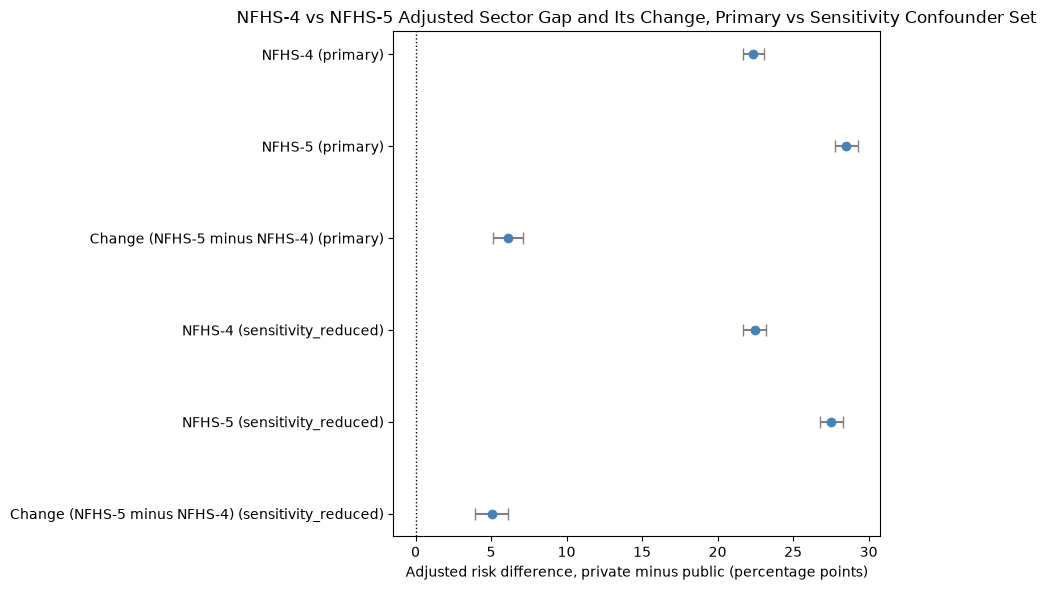

Saved: C:\Users\Tushna\IPD\extensions_work\03_nfhs4_nfhs5_temporal\outputs\temporal_forest_plot.png


In [13]:
plot_rows = [
    ("NFHS-4", "primary", result_nfhs4_primary["risk_difference"] * 100,
     result_nfhs4_primary["rd_ci"][0] * 100, result_nfhs4_primary["rd_ci"][1] * 100),
    ("NFHS-5", "primary", result_nfhs5_primary["risk_difference"] * 100,
     result_nfhs5_primary["rd_ci"][0] * 100, result_nfhs5_primary["rd_ci"][1] * 100),
    ("Change (NFHS-5 minus NFHS-4)", "primary", change_rd_point * 100, change_rd_ci[0] * 100, change_rd_ci[1] * 100),
    ("NFHS-4", "sensitivity_reduced", result_nfhs4_reduced["risk_difference"] * 100,
     result_nfhs4_reduced["rd_ci"][0] * 100, result_nfhs4_reduced["rd_ci"][1] * 100),
    ("NFHS-5", "sensitivity_reduced", result_nfhs5_reduced["risk_difference"] * 100,
     result_nfhs5_reduced["rd_ci"][0] * 100, result_nfhs5_reduced["rd_ci"][1] * 100),
    ("Change (NFHS-5 minus NFHS-4)", "sensitivity_reduced", change_rd_point_reduced * 100,
     change_rd_ci_reduced[0] * 100, change_rd_ci_reduced[1] * 100),
]
plot_df = pd.DataFrame(plot_rows, columns=["label", "confounder_set", "estimate", "ci_low", "ci_high"])
plot_df["row_label"] = plot_df["label"] + " (" + plot_df["confounder_set"] + ")"

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(plot_df))
ax.errorbar(
    plot_df["estimate"], y_pos,
    xerr=[plot_df["estimate"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["estimate"]],
    fmt="o", color="steelblue", ecolor="gray", capsize=4,
)
ax.axvline(0, color="black", linestyle=":", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["row_label"])
ax.invert_yaxis()
ax.set_xlabel("Adjusted risk difference, private minus public (percentage points)")
ax.set_title("NFHS-4 vs NFHS-5 Adjusted Sector Gap and Its Change, Primary vs Sensitivity Confounder Set")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "temporal_forest_plot.png", dpi=200)
plt.show()
print("Saved:", OUTPUTS_DIR / "temporal_forest_plot.png")

## 13. Save metadata

In [22]:
metadata = {
    "random_state": RANDOM_STATE,
    "n_nfhs4": result_nfhs4_primary["n"], "n_nfhs5": result_nfhs5_primary["n"],
    "primary_confounder_set": PRIMARY_CONFOUNDERS,
    "reduced_sensitivity_confounder_set": REDUCED_HARMONIZED_CONFOUNDERS,
    "crosswalk_unverified_confounders": sorted(unverified_confounders),
    "missing_or_degenerate_confounders": missing_or_degenerate,
    "nuisance_models": "identical to notebooks/v2/07, fit independently per round (no pooled nuisance model)",
    "change_estimand": {
        "method": "paired PSU-cluster bootstrap difference: change_b = RD5_reps[b] - RD4_reps[b], "
                   "independent waves; nuisance fits held fixed; survey variance review pending",
        "n_bootstrap": N_BOOTSTRAP,
        "change_in_rd_pct": float(change_rd_point * 100),
        "change_in_rd_ci_pct": [change_rd_ci[0] * 100, change_rd_ci[1] * 100],
    },
    "interpretation_rule": (
        "A change in the adjusted sector gap between rounds is not causal evidence of a specific "
        "policy or programmatic effect; it describes how the cross-sectional adjusted association "
        "moved between two independent survey waves, each under its own round-specific measured-"
        "confounding assumption."
    ),
    "uncertainty_status": "provisional conditional intervals; singleton-PSU and survey design review pending",
    "state_crosswalk": "state_crosswalk.py combines changed state/UT boundaries to 35 common units",
    "known_unresolved_harmonization_issues": [
        "State codes are mapped to 35 common geographic units; aggregation of split/merged territories requires explicit reporting.",
        "Social group labels match in the two supplied Stata codebooks; sensitivity excludes it by pre-specified design.",
        "wealth_index (v190) construction methodology has known cross-round revisions; treated as "
        "ordinal within-round only, not asserted as a continuously comparable scale across rounds.",
    ],
}

with open(OUTPUTS_DIR / "temporal_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print("Saved:", OUTPUTS_DIR / "temporal_metadata.json")

Saved: C:\Users\Tushna\IPD\extensions_work\03_nfhs4_nfhs5_temporal\outputs\temporal_metadata.json


In [23]:
import json
import numpy as np
import pyreadstat

variables = [
    "m15", "m17", "s116", "v024", "v025", "v130", "v133",
    "v190", "bord", "b0", "v001", "v005", "v021", "v022", "v023"
]
raw_paths = {
    "NFHS-4": config.REPO_ROOT / "data/raw/nfhs4/IABR74FL.DTA",
    "NFHS-5": config.REPO_ROOT / "data/raw/IABR7EFL.DTA",
}
frames = {"NFHS-4": nfhs4, "NFHS-5": nfhs5}
fits = {"NFHS-4": result_nfhs4_primary, "NFHS-5": result_nfhs5_primary}

def effective_n(weights):
    weights = np.asarray(weights, dtype=float)
    return float(weights.sum() ** 2 / np.square(weights).sum())

audit = {"rounds": {}}

for wave, frame in frames.items():
    _, meta = pyreadstat.read_dta(str(raw_paths[wave]), metadataonly=True)
    variable_labels = getattr(meta, "column_names_to_labels", {}) or {}
    value_labels = getattr(meta, "variable_value_labels", {}) or {}

    codebook = {
        v: {
            "present": v in meta.column_names,
            "variable_label": variable_labels.get(v),
            "value_labels": {
                str(code): str(label)
                for code, label in value_labels.get(v, {}).items()
            },
        }
        for v in variables
    }

    e = np.asarray(fits[wave]["e_hat_clipped"], dtype=float)
    a = frame["exposure"].to_numpy(dtype=int)
    w = frame["sample_weight_normalized"].to_numpy(dtype=float)
    assert len(e) == len(frame) and np.isfinite(e).all()
    assert np.isfinite(w).all() and (w > 0).all()

    private_share = np.average(a, weights=w)
    ipw = np.where(a == 1, private_share / e, (1 - private_share) / (1 - e))
    combined_w = w * ipw
    psus = frame.groupby("sample_stratum_v022")["cluster_number"].nunique()

    audit["rounds"][wave] = {
        "codebook": codebook,
        "design": {
            "analytic_strata": int(len(psus)),
            "singleton_analytic_strata": int((psus == 1).sum()),
            "stratum_psu_pairs": int(psus.sum()),
            "missing_stratum_rows": int(frame["sample_stratum_v022"].isna().sum()),
            "missing_psu_rows": int(frame["cluster_number"].isna().sum()),
        },
        "overlap": {
            "propensity_percentiles_0_1_5_50_95_99_100": [
                float(x) for x in np.percentile(e, [0, 1, 5, 50, 95, 99, 100])
            ],
            "propensity_below_0_01": int((e < 0.01).sum()),
            "propensity_above_0_99": int((e > 0.99).sum()),
            "stabilized_ipw_above_10": int((ipw > 10).sum()),
            "max_stabilized_ipw": float(ipw.max()),
            "survey_weight_effective_n": effective_n(w),
            "combined_weight_effective_n": effective_n(combined_w),
            "combined_weight_effective_n_public": effective_n(combined_w[a == 0]),
            "combined_weight_effective_n_private": effective_n(combined_w[a == 1]),
        },
    }
    print(wave, "diagnostics calculated")

output_path = OUTPUTS_DIR / "ext3_remaining_checks.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(audit, f, indent=2)

print("Saved:", output_path)

NFHS-4 diagnostics calculated
NFHS-5 diagnostics calculated
Saved: C:\Users\Tushna\IPD\extensions_work\03_nfhs4_nfhs5_temporal\outputs\ext3_remaining_checks.json


In [24]:
for wave, frame in frames.items():
    design_raw, _ = pyreadstat.read_dta(
        str(raw_paths[wave]), usecols=["v001", "v021", "v022", "v023"]
    )
    full_psus = design_raw.groupby("v022")["v001"].nunique()
    analytic_psus = frame.groupby("sample_stratum_v022")["cluster_number"].nunique()
    singleton_codes = analytic_psus[analytic_psus == 1].index
    affected = frame["sample_stratum_v022"].isin(singleton_codes)

    print(
        wave,
        "v001 != v021:", int((design_raw["v001"] != design_raw["v021"]).sum()),
        "v022 != v023:", int((design_raw["v022"] != design_raw["v023"]).sum()),
        "full-survey singleton strata:", int((full_psus == 1).sum()),
        "analytic singleton strata:", len(singleton_codes),
        "births in analytic singleton strata:", int(affected.sum()),
        "their survey-weight share:",
        round(frame.loc[affected, "sample_weight_normalized"].sum()
              / frame["sample_weight_normalized"].sum() * 100, 4), "%",
    )

NFHS-4 v001 != v021: 0 v022 != v023: 0 full-survey singleton strata: 9 analytic singleton strata: 11 births in analytic singleton strata: 80 their survey-weight share: 0.1217 %
NFHS-5 v001 != v021: 0 v022 != v023: 0 full-survey singleton strata: 16 analytic singleton strata: 16 births in analytic singleton strata: 117 their survey-weight share: 0.0817 %


## 14. Interpretation

Independent wave-specific nuisance fits avoid imposing one model over the two
survey waves. The adjusted difference in gaps compares estimates standardized
to each wave's own covariate distribution; it may reflect changes in population
composition as well as sector associations. The state codes have been mapped
to common names with changed territories combined. The reduced sensitivity
omits state and social group by design. Fixed-nuisance PSU bootstrap intervals
are conditional and require survey-methods review. No policy effect is claimed.
